In [1]:
import numpy as np
import hyperspy.api as hs

In [2]:
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import colorcet as cc

In [3]:
from scipy.ndimage import rotate

In [6]:
import stem_analysis.plot as saplt

In [7]:
import os

In [8]:
%matplotlib widget

In [9]:
work_dir = '/Users/nihy/Desktop/Working Data/EuAl4/Good Data/CBED'

In [12]:
dp_path = os.path.join(work_dir, "100K.dm4")

In [14]:
dp = hs.load(dp_path)
dp.axes_manager

Signal axis name,size,,offset,scale,units
x,4096,,-0.0,0.013114077039062977,1/nm
y,4096,,-0.0,0.013114077039062977,1/nm


In [15]:
dq = dp.axes_manager[0].scale/2

In [19]:
0.026228/(dq*2)*800

1599.9906007490733

In [17]:
def PlotDiff(dp, dq, norm = 'log', cmap = cc.cm. fire, vmin_percentile = 1, vmax_percentile = 99.9):
    plt.figure(figsize = (10, 10))
    plt.subplots_adjust(0, 0.15, 1, 1)
    plt.imshow(dp, 
               norm = norm, cmap = cmap, 
               vmin = np.percentile(dp, vmin_percentile), 
               vmax = np.percentile(dp, vmax_percentile))

    ax = plt.gca()
    scalebar = ScaleBar(dq, 
                                 "1/nm",
                                 dimension = "si-length-reciprocal",
                                 location = 'lower right',
                                 frameon = False,
                                 length_fraction = 0.25,    
                                 height_fraction = 0.02,
                                 bbox_to_anchor=(1, -0.12),
                                 bbox_transform =ax.transAxes,
                                 font_properties = {'size': 32},)
    ax.add_artist(scalebar)
    ax.axis("off")
    plt.show()

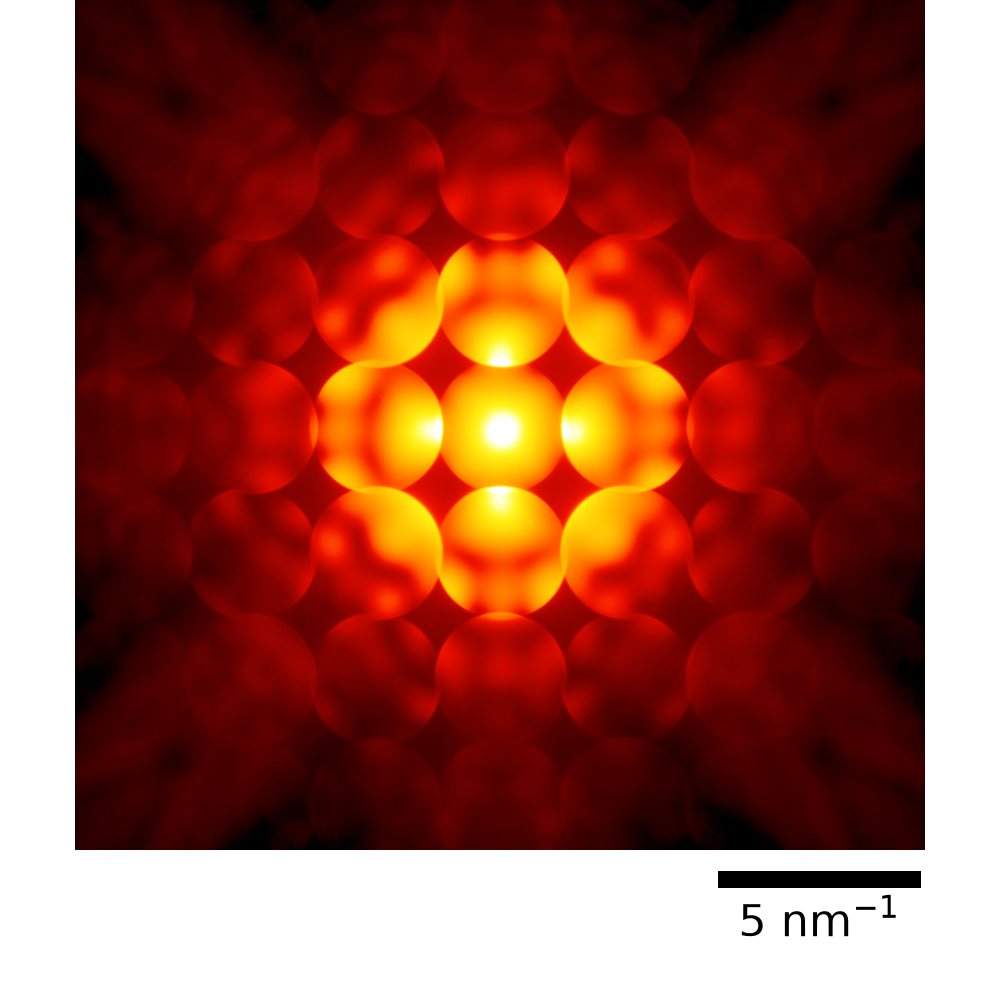

In [21]:
PlotDiff(rotate(dp,77-90,reshape = True)[2530 - 1066: 2530 + 1066,2493 - 1066: 2493 + 1066], dq)
plt.savefig(os.path.join(work_dir, "300K.svg"), dpi = 300, pad_inches = 0, transparent = True)

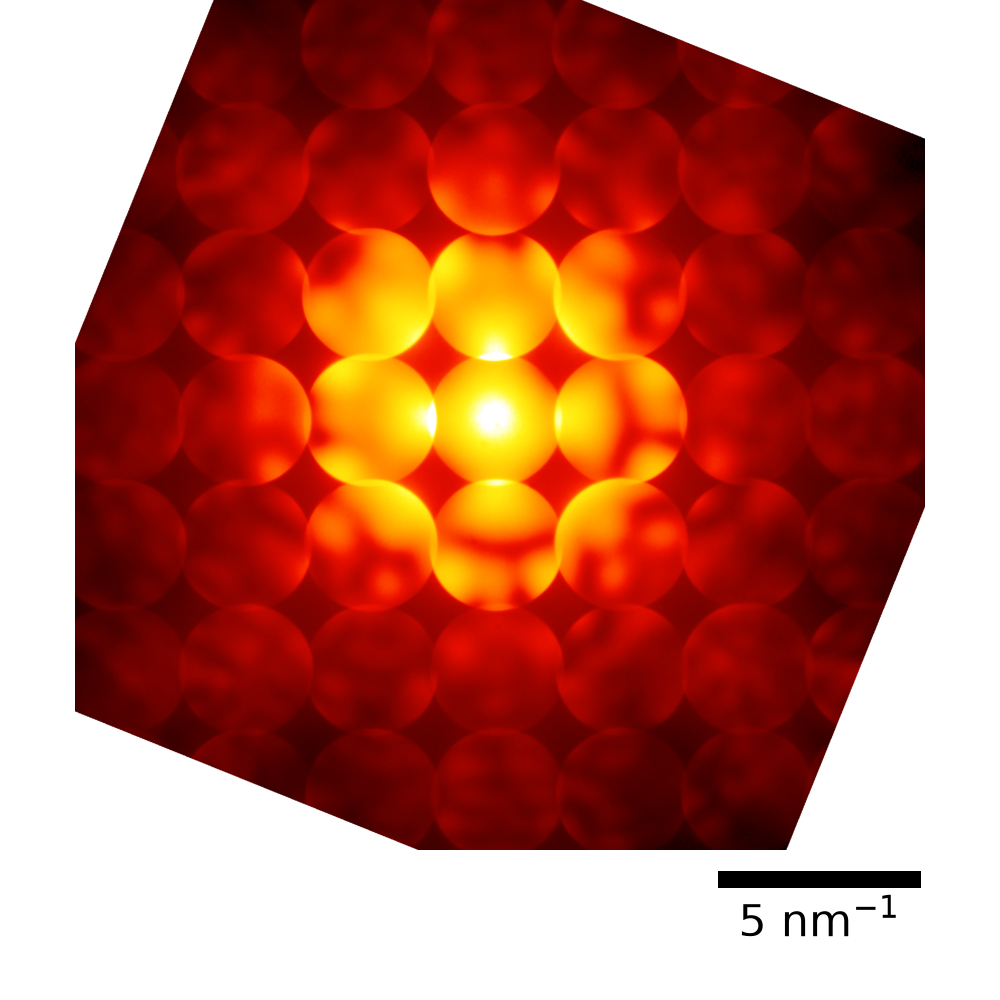

In [51]:
plt.figure(figsize = (10, 10))
plt.subplots_adjust(0, 0.15, 1, 1)
plt.imshow(rotate(dp[2150 - 800: 2150 + 800,2140 - 800: 2140 + 800],68,reshape = False), 
           norm = 'log', cmap = cc.cm.fire, vmin = np.percentile(dp[2150 - 800: 2150 + 800,2140 - 800: 2140 + 800], 1), 
           vmax = np.percentile(dp[2150 - 800: 2150 + 800,2140 - 800: 2140 + 800], 99.9))

ax = plt.gca()
scalebar = ScaleBar(dq, 
                             "1/nm",
                             dimension = "si-length-reciprocal",
                             location = 'lower right',
                             frameon = False,
                             length_fraction = 0.25,    
                             height_fraction = 0.02,
                             bbox_to_anchor=(1, -0.12),
                             bbox_transform=ax.transAxes,
                             font_properties = {'size': 32},)
ax.add_artist(scalebar)
ax.axis("off")
plt.savefig(os.path.join(work_dir, "5K.svg"), dpi = 300, pad_inches = 0, transparent = True)

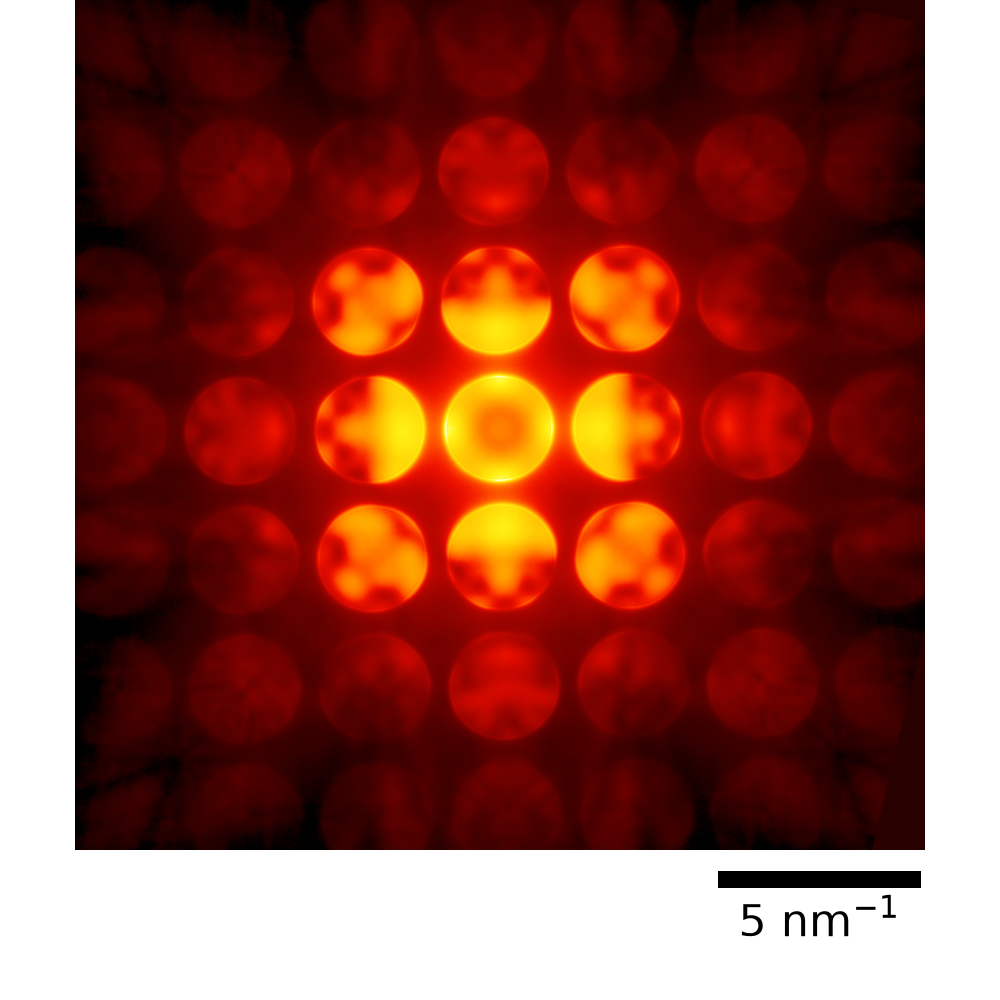

In [32]:
saplt.PlotDiff(rotate(dp.data, 76.39, cval = 6e3)[2345-1600:2345+1600,2823-1600:2823+1600], dq, vmin_percentile=1, vmax_percentile=100)
plt.savefig(os.path.join(work_dir, "diff_plot.svg"), dpi = 300, pad_inches = 0, transparent = True)